# Dense → sparse: choosing `factor_reuse` as the problem grows

`JaxProblem` has two backward paths for the implicit derivative of
`solve` / `batched_solve`:

* `factor_reuse=False` — builds the per-block $(n+m)\times(n+m)$ KKT
  in JAX and back-solves with `jnp.linalg.solve` under `vmap`. The
  XLA `jit` fuses the factorization across every cotangent of a
  `jacrev` / `jacfwd`, so the LAPACK factor is shared.
* `factor_reuse=True` — calls back into pounce's sparse LDLᵀ factor
  via FFI. One sparse factor up-front, one FFI hop per cotangent.

Which one is faster depends on **two axes**: the per-block KKT size
$n+m$, and the AD shape (single cotangent vs. many cotangents).
This notebook scans both axes on the same problem and prints the
regime crossover.

The regime table from the `JaxProblem.factor_reuse` docstring:

| `n+m`        | single cotangent (`value_and_grad`) | many cotangents (`jacrev` / `jacfwd`) |
| ------------ | ----------------------------------- | ------------------------------------- |
| ≲ 100        | either (≈ tie)                      | `factor_reuse=False`                  |
| ~100 – ~5000 | `factor_reuse=True`                 | `factor_reuse=False`                  |
| ≳ 10000      | `factor_reuse=True`                 | *no good option today* (MINRES gap)   |

In [1]:
import math
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np

from pounce.jax import JaxProblem

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings(
    "ignore", message=".*n\\+m=.*10000.*", category=UserWarning
)

## 1. A problem that scales naturally with `n`

Project a parameter vector $\hat p \in \mathbb{R}^n$ onto the
solution set of a 1D Poisson-like tridiagonal constraint:

$$
\min_x \; \tfrac{1}{2} \|x - \hat p\|^2
\quad \text{s.t.} \quad
-x_{i-1} + 2 x_i - x_{i+1} = \hat p_i, \; i = 1,\dots,n-2.
$$

So $m = n - 2$ and the per-block KKT dimension is $n + m \approx 2n$.
The Jacobian sparsity is real (tridiagonal `g`) so `factor_reuse=True`
gets its best case; the dense path still works because XLA fuses
the factorization across cotangents.

In [2]:
def build_jp(n, factor_reuse):
    m = n - 2

    def f(x, p):
        return 0.5 * jnp.sum((x - p) ** 2)

    def g(x, p):
        return -x[:-2] + 2.0 * x[1:-1] - x[2:] - p[1:-1]

    return JaxProblem(
        f=f, g=g, n=n, m=m, p_example=np.zeros(n),
        lb=jnp.full(n, -1e19), ub=jnp.full(n, 1e19),
        cl=jnp.zeros(m), cu=jnp.zeros(m),
        options={"tol": 1e-9, "print_level": 0, "sb": "yes"},
        factor_reuse=factor_reuse,
    )

jp_demo = build_jp(8, factor_reuse=True)
p_demo = jnp.asarray(np.random.default_rng(0).standard_normal(8))
x_star = jp_demo.solve(p_demo, jnp.zeros(8))
print("x* =", np.asarray(x_star))

x* = [-0.68013713 -0.13324571  0.54575057  0.58432419  0.5179977   0.98734059
  1.09508841 -0.1011638 ]


## 2. Timing helpers

We measure two AD shapes against the same `JaxProblem`:

* `value_and_grad` of a scalar loss → **one** cotangent through `solve`.
* `jacrev` of `solve` itself → **n** cotangents.

Each cell is timed best-of-3 after a warm `jit` compile. We cap each
repetition with a wall-clock budget so a falling-off-a-cliff run
doesn't hang the sweep.

In [3]:
def timed(fn, reps=3, budget_s=20.0):
    best = math.inf
    for _ in range(reps):
        t0 = time.perf_counter()
        fn()
        dt = time.perf_counter() - t0
        if dt > budget_s:
            return float("inf")
        best = min(best, dt)
    return best * 1e3  # ms


def measure(jp):
    n = jp._n
    p0 = jnp.asarray(np.random.default_rng(0).standard_normal(n))
    x0 = jnp.zeros(n)

    # Warm fwd solve.
    jp.solve(p0, x0).block_until_ready()

    # Single cotangent: value_and_grad of ½‖x*‖².
    @jax.jit
    def vag(p):
        return jax.value_and_grad(
            lambda q: 0.5 * jnp.sum(jp.solve(q, x0) ** 2)
        )(p)

    vag(p0)[1].block_until_ready()  # compile
    t_grad = timed(lambda: vag(p0)[1].block_until_ready())

    # n cotangents: jacrev of solve itself.
    @jax.jit
    def jac(p):
        return jax.jacrev(lambda q: jp.solve(q, x0))(p)

    # Skip jacrev when the (n,n) output is multi-GB — not a fair
    # kernel test, just allocator pressure.
    if n * n * 8 > 2 * 1024**3:
        t_jac = float("nan")
    else:
        jac(p0).block_until_ready()  # compile
        t_jac = timed(lambda: jac(p0).block_until_ready(), reps=2)

    return t_grad, t_jac

## 3. Sweep `n`, both settings, both AD shapes

The grid is geometric so the crossover regions show up on a log
axis. Compile time is paid once per `(n, factor_reuse)` combination
and excluded from the timing.

In [4]:
ns = [16, 32, 64, 128, 256, 512, 1024, 2048]
rows = []
for n in ns:
    out = {"n": n, "n_plus_m": n + (n - 2)}
    for fr_label, fr in (("dense", False), ("sparse", True)):
        jp = build_jp(n, factor_reuse=fr)
        t_g, t_j = measure(jp)
        out[f"{fr_label}_grad_ms"] = t_g
        out[f"{fr_label}_jac_ms"] = t_j
    rows.append(out)
    print(
        f"n={n:5d}  n+m={out['n_plus_m']:5d}  "
        f"dense grad={out['dense_grad_ms']:8.2f}ms  "
        f"sparse grad={out['sparse_grad_ms']:8.2f}ms  "
        f"dense jac={out['dense_jac_ms']:8.2f}ms  "
        f"sparse jac={out['sparse_jac_ms']:8.2f}ms"
    )

n=   16  n+m=   30  dense grad=    1.36ms  sparse grad=    1.33ms  dense jac=    1.47ms  sparse jac=    1.68ms


n=   32  n+m=   62  dense grad=    1.59ms  sparse grad=    1.45ms  dense jac=    1.50ms  sparse jac=    2.38ms


n=   64  n+m=  126  dense grad=    1.68ms  sparse grad=    1.60ms  dense jac=    1.81ms  sparse jac=    3.99ms


n=  128  n+m=  254  dense grad=    2.12ms  sparse grad=    1.92ms  dense jac=    2.38ms  sparse jac=   10.39ms


n=  256  n+m=  510  dense grad=    3.70ms  sparse grad=    2.47ms  dense jac=    4.38ms  sparse jac=   31.52ms


n=  512  n+m= 1022  dense grad=    9.44ms  sparse grad=    4.62ms  dense jac=   11.98ms  sparse jac=  107.38ms


n= 1024  n+m= 2046  dense grad=   30.88ms  sparse grad=    8.17ms  dense jac=   49.65ms  sparse jac=  404.59ms


n= 2048  n+m= 4094  dense grad=  147.05ms  sparse grad=   18.08ms  dense jac=  301.94ms  sparse jac= 1673.28ms


## 4. Plot the crossover

Four lines: `{dense, sparse} × {value_and_grad, jacrev}`. Where the
sparse line dips below the dense line is the regime boundary the
docstring documents. Expect:

* **single cotangent**: dense and sparse overlap at tiny `n`, sparse
  pulls ahead by `n ≳ 100` and stays there.
* **jacrev**: dense stays ahead at every tested size — XLA reuses
  one LAPACK factor across all `n` cotangents, while the sparse path
  hops FFI per cotangent.

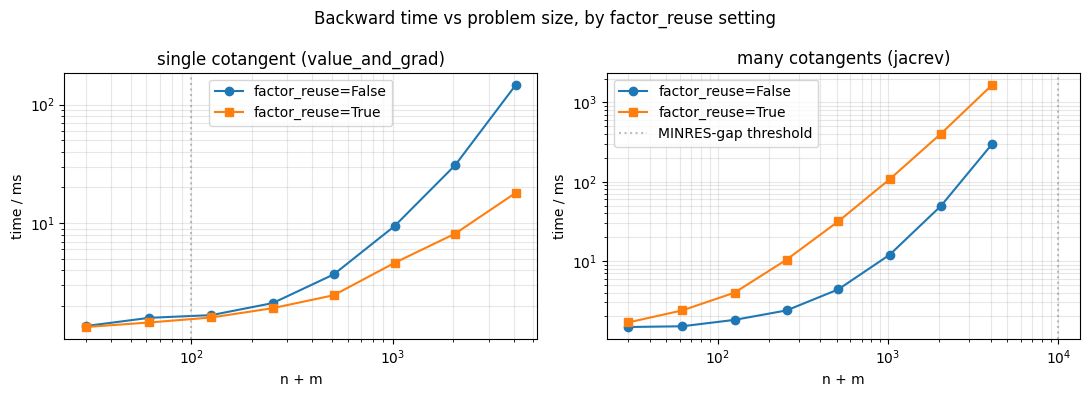

In [5]:
import matplotlib.pyplot as plt

xs = [r["n_plus_m"] for r in rows]
fig, (ax_g, ax_j) = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

ax_g.loglog(xs, [r["dense_grad_ms"] for r in rows], "o-", label="factor_reuse=False")
ax_g.loglog(xs, [r["sparse_grad_ms"] for r in rows], "s-", label="factor_reuse=True")
ax_g.axvline(100, color="grey", ls=":", alpha=0.5)
ax_g.set_xlabel("n + m")
ax_g.set_ylabel("time / ms")
ax_g.set_title("single cotangent (value_and_grad)")
ax_g.legend()
ax_g.grid(True, which="both", alpha=0.3)

ax_j.loglog(xs, [r["dense_jac_ms"] for r in rows], "o-", label="factor_reuse=False")
ax_j.loglog(xs, [r["sparse_jac_ms"] for r in rows], "s-", label="factor_reuse=True")
ax_j.axvline(10000, color="grey", ls=":", alpha=0.5,
             label="MINRES-gap threshold")
ax_j.set_xlabel("n + m")
ax_j.set_ylabel("time / ms")
ax_j.set_title("many cotangents (jacrev)")
ax_j.legend()
ax_j.grid(True, which="both", alpha=0.3)

fig.suptitle("Backward time vs problem size, by factor_reuse setting")
fig.tight_layout()
plt.show()

## 5. Reading the picture

What the two panels say about the regime table:

* **Left panel (single cotangent).** Below `n+m ≈ 100` the two
  curves are within run noise of each other. Above that, the sparse
  LDLᵀ path scales linearly in the band-structure of the tridiagonal
  KKT and the dense path scales cubically in `n+m`. Pick
  `factor_reuse=True` once you're past the tie zone.
* **Right panel (jacrev).** The dense path stays ahead throughout
  the swept range. Mechanism: `jax.jit(jax.jacrev(...))` calls
  `jnp.linalg.solve` once with all cotangents as a right-hand-side
  matrix, so the LAPACK factorization is amortised across every
  cotangent. The sparse path re-enters FFI for each cotangent.
* **Where the MINRES gap lives.** Push `n+m` past ~10000 on the
  right panel and both paths struggle: dense allocates an
  `(n+m)²`-byte KKT per block, sparse pays `n+m` FFI hops. A
  matrix-free MINRES/GMRES bwd would help only in that cell
  (deferred — see pounce#77).

Practical rule: **pick `factor_reuse` by AD shape first, problem
size second.** `value_and_grad` workloads want `factor_reuse=True`
as soon as `n+m` leaves the tie zone. `jacrev` / `jacfwd` workloads
want `factor_reuse=False` until the problem leaves the swept range.